# Autonomous Systems Portfolio 1  
***Connect 4 met Rule Based Systems***

![Connect4](https://upload.wikimedia.org/wikipedia/commons/a/ad/Connect_Four.gif)  
([Wikipedia, 4 Okt 2025](https://nl.wikipedia.org/wiki/Vier_op_%27n_rij))
|Name     |Studentnumber|Github    |
|---------|-------------|----------|
|Henry Lau|22122958     |HenryLau08|
|Michal Reszka-Gniecki|23025069|ckires|
|Mohamed Belaachir|22143572|mobelaachir|

## Inhoudsopgave



## 1. Introductie

### 1.1 Achtergrond  
#### 1.1.1. Connect 4
Connect 4 is een twee speler bordspel, waarbij spelers om de beurt een schrijf laten vallen in een kolom van een 7x6 boord. De speler die als eerste vier schijven op een rij krijgt (horizontaal, diagonaal of verticaal) wint. Wij hebben voor deze spel gekozen, omdat wij meer uitdaging wilden dan bij tic-tac-toe, maar tegelijkertijd niet gelijk in de diepe worden gegooid net als bij b.v. Mario.
Bij connect 4 zijn alle situaties op het bord in principe voorspelbaar en elke strategie wordt zo moeilijk als je het zelf maakt. Door het feit dat het raster een bepaald grootte heeft (7x6) en de bewegingen in principe beperkt zijn tot: winnen, blokkeren, positie innemen, leekt het ons een perfect spel om de rule-based systeem voor te bouwen.

#### 1.1.2. Probleemstelling
Omdat alle keuzes in connect 4 voorspelbaar zijn, is de rule-based aanpak het meest gunstig. Al hoewel Machine Learning tot vergelijkbare strategiën kunnen komen, is rule-based handiger om twee redenen. Ten eerste is de rule-based aanpak overzichtelijk en verzin duidelijk waarom strategie een bepaald keuze heeft gemaakt. Ten tweede rule-based kost minder tijd wekkend.

### 1.2. Doel van de opdracht
Het doel van dit project is om aantal rulebased strategieen te bouwen die zelfstandig beslissingen kunnen nemen tijdens het spel. Alhoewel winnen een leuke extra is, het gaat hierbij vooral om de basis van rule-based systeem te leren.

### 1.3. Rule based systeem
Een rule based systeem is een systeem dat beslissingen maakt op basis van de vooraf ingestelde regels, die meestal in de vorm 'if-then' geschreven zijn.
Huidige situatie (genoemd state) wordt bijgehouden in working memory. Dit is een verzameling van alle kennis, die na elke stap wordt bijgewerkt.
Op basis van de huidige situatie voert het systeem een bepaald actie uit. ([Wikipedia, 27 Juli 2025](https://en.wikipedia.org/wiki/Rule-based_system)).  

Een voordeel van een rule-based systeem is dat het duidelijk is hoe keuzes worden gemaakt. Dankzij deze overzicht kan je relatief makkelijk achterhalen welke regel nu uitgevoerd is of waarom een actie genomen is. Om die reden is het ook makkelijk om je strategie aan te passen, je hoeft namelijk alleen de functies veranderen.

Een nadeel is dat alle regels van tevoren gemaakt zijn, wat dat betekent dat het systeem minder goed of helemaal niet om kan gaan met nieuwe of onverwachte situaties. Bovendien kan de strategie of jouw code heel onoverzichtelijk worden als de code te lang wordt of niet volgens de programmeerprincipes is geschreven, bijvoorbeeld DRY (Dont repeat yourself).
Tweede nadeel is conflicten. Het is mogelijk, vooral bij een uitgebreid systeem dat meerdere regels tegelijkertijd kunnen matchen. ([ScienceDirect, 2025](https://www.sciencedirect.com/topics/engineering/rule-based-system)).  

Rule-based systemen zijn nogsteeds handig in situaties waar het probleem duidelijk is en de regels makkelijk te bepalen zijn voor alle mogelijke situaties ([GeeksforGeeks, 6 Aug 2025](https://www.geeksforgeeks.org/machine-learning/rule-based-system-vs-machine-learning-system/)).

## 2. Set Rules

### "Smart" Strategy

Er wordt een vaste volgorde van regels gebruikt om actie te nemen op basis van de situatie en mogelijkheden.

Regels:
1. Win  

            Als de agent kan winnen in deze beurt, dan kiest hij dat kolom.
2. Block Win  

            Als de tegenstander kan winnen in de volgende beurt, blokkeert de agent dit.
3. Block Fork  

            Als de tegenstander een fork kan maken, gaat het agent dit op tijd blokkeren.
4. Fork  

            Als de agent zelf een fork kan maken, doet hij dat.
5. Center  

            Als het midden vrij is, speelt de agent in het midden.
6. Random  

            Als geen van de bovenstaande regels geldt, dan speelt de agent willekeurig een beschikbare kolom.

De regels zijn geordend op basis van prioriteit:  
Als het agent kan winnen, dan speelt hij daar en eindigt het spel. Als tegenstander kan winnen of een fork kan maken op de volgende beurt, dan zal de agent dit blokkeren. Anders speelt het agent in het midden of willekeurig als midden niet meer beschikbaar is.

Een voorbeeld is als de agent op zijn beurt kan winnen en de tegenstander ook 3 schijven bij elkaar hebben, dan is de prioriteit om zijn eigen 4 te maken om te winnen en niet blokkeren.


### Defensive Strategy
Deze strategie bouwt voort op 'smart strategy' met drie verbeteringen.
- Actief een fork bouwen
- fork blokkeren is slimmer
- trap awarness (zetten vermijden die gratis win geven aan de tegenstander)

Regels:
1. Win

            Als we kunnen winnen, kiezen we die kolom.
2. Win blokkeren

            Als de tegenstander de volgende beurt kan winnen, blokkeren we dit.
3. Fork

            Als we een fork kunnen maken (≥2 winnende dreigingen tegelijk), kiezen we de veiligste. Dat betekent de fork waarbij de tegenstander daarna de minste winnende opties heeft.
4. Naar fork bouwen

            Als er nog geen fork mogelijk is, kiezen we de kolom die ons de meeste fork mogelijkheden geeft. 
            De beste kolom is de kolom waarbij daarna de meeste kolommen een fork zouden maken. Zo proberen wij actief winnen i.p.v. alleen reageren.
5. Fork blokkeren

            Als de tegenstander een fork kan maken, kiezen we de kolom die hem de minste winnende opties overlaat. Dit bepalen we door voor elke kolom te simuleren hoeveel winnende zetten de tegenstander daarna nog heeft. De kolom met het laagste aantal wint.
6. Valstrik vermijden

            We vermijden kolommen waarbij de cel direct boven onze geplaatste balletje een 'gratis' win geeft aan de tegenstander. Een valstrik is wanneer we door onze zet de rij erboven vrijmaken voor winnende positie voor de tegenstander. Dit tellen wij bij elke zet.
7. Center

            Als kolom 3 beschikbaar (en veilig) is, spelen we daar.
8. Voorkeursvolgorde

            Als geen van de bovenstaande regels geldt, spelen we van binnen naar buiten: kolom 2, 4, 1, 5, 0, 6.

De volgorde van de regels is op prioriteit geordend. Winnen gaat altijd voor. Daarna blokkeren we de tegenstander als die kan winnen. Het grote verschil met 'smart_strategy' is dat we niet alleen reageren, maar ook toewerken naar een fork. Als er nog geen fork mogelijk is, kiezen we de zet die ons het dichtst bij een fork brengt. Bij het blokkeren van een fork kiezen we niet zomaar de eerste mogelijkheid, maar de veiligste zet. Daarnaast controleren we ook bij elke zet of we niet per ongeluk een valstrik bouwen voor onszelf.


### Geef Niet Op

- geef_niet_op_strategy(board, mask, player): Dit is de hersenen van de computer. De computer kijkt eerst of hij zelf kan winnen, of dat hij jou kan blokkeren zodat jij niet wint. Als dat niet kan, zoekt hij naar "veilige" zetten. Een veilige zet is een zet waarbij jij niet direct daarna kunt winnen. Als er meerdere veilige zetten zijn, kiest de computer het liefst een kolom in het midden van het bord, omdat dat vaak de beste plek is. Als er geen veilige zetten zijn, kiest de computer gewoon een willekeurige lege kolom.  

Geef Niet Op strategie, die in de functie geef_niet_op_strategy zit, is een slimme manier voor de computer om Vier op een Rij te spelen.

Regels:
1. Direct winnen of blokkeren: 

            De computer kijkt eerst of hij in de volgende zet zelf kan winnen. Als dat zo is, doet hij die zet. Als hij niet zelf kan winnen, kijkt hij of jij in de volgende zet kunt winnen. Als dat zo is, blokkeert hij jou door zijn schijfje daar neer te leggen.
2. Veilige zetten zoeken:  

            Als de computer niet direct kan winnen of jou kan blokkeren, zoekt hij naar "veilige" zetten. Een veilige zet is een zet waarbij jij niet direct daarna kunt winnen. De computer wil niet dat jij een makkelijke winst krijgt.
3. Midden van het bord is belangrijk:  

            Als er meerdere veilige zetten zijn, kiest de computer het liefst een kolom in het midden van het bord (kolom 3, dan 2, dan 4, enzovoort). Dit is vaak een goede plek om te spelen, omdat je vanuit het midden makkelijker rijen van vier kunt maken.
4. Willekeurige zet (als niets anders kan):  

            Als er geen slimme of veilige zetten zijn, kiest de computer gewoon een willekeurige lege kolom. Dit gebeurt alleen als er echt geen betere optie is.  

De computer probeert altijd eerst te winnen of jou te stoppen, dan veilig te spelen, en kiest het liefst het midden van het bord.

### One to Five

One to Five strategie, die in de functie one_to_five_strategy zit, lijkt op de Smart-strategie maar heeft één belangrijk verschil: in plaats van het midden van het bord te verkiezen, kiest de computer bij gebrek aan een slimme zet gewoon willekeurig uit de kolommen 1 tot en met 5. Zo vermijdt hij de buitenste randen zonder een vaste voorkeur voor het exacte midden.
Regels:

1. Direct winnen:

            De computer kijkt eerst of hij in de volgende zet zelf kan winnen. Als dat zo is, doet hij meteen die zet. Winnen heeft altijd de hoogste prioriteit.
2. Blokkeren:

            Als de computer niet zelf kan winnen, kijkt hij of jij in de volgende zet kunt winnen. Als dat zo is, legt hij zijn schijfje precies daar neer om jou te stoppen.
3. Fork van de tegenstander blokkeren:

            Als de computer niet hoeft te winnen of te blokkeren, kijkt hij of jij een "fork" kunt maken. Een fork is een situatie waarin jij op twee verschillende plekken tegelijk kunt winnen, zodat de computer niet alles kan blokkeren. Als de computer zo'n fork ziet aankomen, probeert hij die te voorkomen door de sleutelkolom te bezetten.
4. Zelf een fork maken:

            Als er geen dreiging van jou is, zoekt de computer of hij zelf een fork kan opzetten. Door twee winnende mogelijkheden tegelijk te creëren, dwingt hij jou in een onmogelijke situatie.
5. Willekeurige zet tussen kolom 1 en 5:

            Als geen van de bovenstaande regels een zet oplevert, kiest de computer willekeurig een kolom uit kolommen 1 tot en met 5. Hij vermijdt bewust de buitenste kolommen 0 en 6, maar heeft verder geen voorkeur voor een specifieke kolom. Als kolommen 1 tot en met 5 allemaal vol zijn, kiest hij willekeurig uit alle nog beschikbare kolommen.

De computer probeert altijd eerst te winnen, dan te blokkeren, dan gevaarlijke situaties te voorkomen, dan zelf een voordeel op te bouwen, en kiest pas als laatste willekeurig tussen de middelste kolommen.

## 3. Game

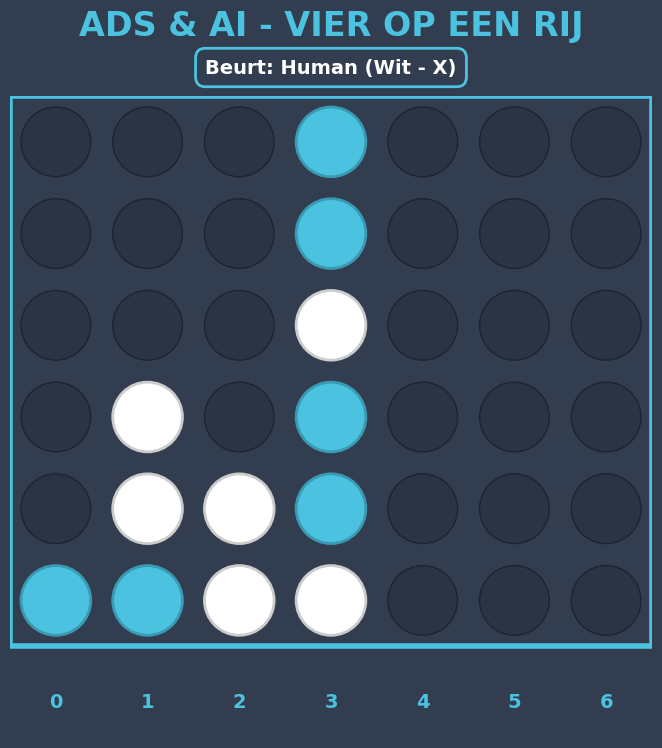

In [ ]:
from pettingzoo.classic import connect_four_v3
import matplotlib.pyplot as plt
import time
import asyncio
import ipywidgets as widgets
from Board import convert_observation, create_game_ui, print_text_board, clear_output
from strategies import random_strategy, smart_strategy, defensive_strategy, geef_niet_op_strategy, one_to_five_strategy, HumanWidgetStrategy

_human_strategy = HumanWidgetStrategy()

# Beschikbare strategieën, inclusief de menselijke speler
STRATEGIES = {
    "Human": _human_strategy,
    "Random": random_strategy,
    "Smart": smart_strategy,
    "Defensive": defensive_strategy,
    "Geef Niet Op": geef_niet_op_strategy,
    "One to Five": one_to_five_strategy,
}

# Dropdown voor speler 0
player0_dropdown = widgets.Dropdown(
    options=list(STRATEGIES.keys()),
    value="Human",
    description="Player 0:",
    style={'description_width': 'initial'}
)

# Dropdown voor speler 1
player1_dropdown = widgets.Dropdown(
    options=list(STRATEGIES.keys()),
    value="Smart",
    description="Player 1:",
    style={'description_width': 'initial'}
)

# Knop om het spel te starten
start_button = widgets.Button(
    description="Start Game",
    button_style="success",
    tooltip="Click to start Connect Four",
    icon="play"
)

display(player0_dropdown, player1_dropdown, start_button)


# ---------------------------------------------------------------------------
# Asynchrone spellus
# ---------------------------------------------------------------------------

async def run_game_async():
    """
    Voer één interactief Connect Four-spel asynchroon uit in Jupyter.

    Start een nieuwe ``connect_four_v3``-omgeving en doorloopt de
    beurtenlus totdat het spel afgelopen is. Na elke zet wordt het
    bord opnieuw getekend via ``create_game_ui`` en ``print_text_board``.
    Zowel synchrone strategiefuncties als asynchrone strategie-objecten
    (met een ``get_action``-coroutine) worden ondersteund.

    Parameters
    ----------
    Geen. De functie leest de gekozen strategieën rechtstreeks uit
    ``player0_dropdown.value`` en ``player1_dropdown.value``.

    Returns
    -------
    None
        De functie toont het spelverloop in de Jupyter-uitvoer en
        geeft geen waarde terug.

    Raises
    ------
    TypeError
        Als een strategie-object noch een ``get_action``-coroutine
        noch een aanroepbaar object is.

    Notes
    -----
    - Synchrone strategiefuncties worden via
      ``asyncio.get_event_loop().run_in_executor`` in een aparte
      thread uitgevoerd om de Jupyter-eventloop niet te blokkeren.
    - De spelernamen worden vóór de lus eenmalig vastgelegd in
      ``names``, zodat dropdown-wijzigingen tijdens het spel geen
      invloed hebben op de weergave.
    - De omgeving gebruikt altijd zaad ``42`` voor reproduceerbaarheid
      van de begintoestand.

    Examples
    --------
    >>> await run_game_async()   # Alleen uitvoerbaar in een Jupyter-cel
    """
    env = connect_four_v3.env(render_mode="rgb_array")
    env.reset(seed=42)

    strat_p0 = STRATEGIES[player0_dropdown.value]
    strat_p1 = STRATEGIES[player1_dropdown.value]

    # Sla de spelernamen op vóór de lus zodat dropdownwijzigingen geen invloed hebben
    names = (player0_dropdown.value, player1_dropdown.value)

    for agent in env.agent_iter():
        raw_obs, reward, termination, truncation, info = env.last()
        board          = convert_observation(raw_obs["observation"], agent)
        mask           = raw_obs["action_mask"]
        current_player = 1 if agent == "player_0" else 2

        # Wis de vorige uitvoer voor een vloeiende weergave
        clear_output(wait=True)

        if termination or truncation:
            # Bepaal de eindstatus op basis van de beloning
            if reward == 1:
                winner = names[0] if agent == "player_0" else names[1]
                status = f"{winner} GEWONNEN!"
            elif reward == -1:
                winner = names[1] if agent == "player_0" else names[0]
                status = f"{winner} GEWONNEN!"
            else:
                status = "GELIJKSPEL!"

            # Toon het eindscherm en stop de lus
            create_game_ui(board, current_player, status, player_names=names)
            plt.show()
            print_text_board(board, mask)
            break

        # Toon het huidige bord voor de volgende zet
        create_game_ui(board, current_player, player_names=names)
        plt.show()
        print_text_board(board, mask)

        strat = strat_p0 if agent == "player_0" else strat_p1

        # Kies de zet: asynchroon via get_action of synchroon via executor
        if asyncio.iscoroutinefunction(getattr(strat, "get_action", None)):
            action = await strat.get_action(board, mask, current_player)
        elif callable(strat):
            action = await asyncio.get_event_loop().run_in_executor(
                None, strat, board, mask, current_player
            )
        else:
            raise TypeError(f"Onbekend strategietype: {type(strat)}")

        env.step(action)

    env.close()


# ---------------------------------------------------------------------------
# Knop-handler — start de asynchrone spellus
# ---------------------------------------------------------------------------

def on_start_clicked(b):
    """
    Verwerk een klik op de startknop en start een nieuw spel.

    Zet de asynchrone coroutine ``run_game_async`` in de wachtrij van
    de actieve Jupyter-eventloop via ``asyncio.ensure_future``.

    Parameters
    ----------
    b : ipywidgets.Button
        Het knopobject dat de klikgebeurtenis heeft veroorzaakt.
        Wordt niet direct gebruikt, maar is vereist door de
        ``on_click``-callback-interface van ipywidgets.

    Returns
    -------
    None

    Notes
    -----
    ``asyncio.ensure_future`` werkt alleen correct wanneer er al een
    actieve eventloop draait, wat in Jupyter Notebook en JupyterLab
    standaard het geval is.

    Examples
    --------
    >>> start_button.on_click(on_start_clicked)   # Koppel de handler aan de knop
    """
    # Plan de spellus in op de bestaande Jupyter-eventloop
    asyncio.ensure_future(run_game_async())

start_button.on_click(on_start_clicked)

## 4. Situaties

|Screenshots                                                                  |Uitleg|
|-----------------------------------------------------------------------------|------|
|<img src="Screenshots/smart_fork.png" alt="image" width="400" height="300" />|fork op tijd blokeren|
|<img src="Screenshots/smart_win_over_block.png" alt="image" width="400" height="300" />|win kiezen|
|<img src="Screenshots/gno_no_fork.png" alt="image" width="400" height="300" />|niet op tijd geblokkeerd|
|<img src="Screenshots/def_skip2.png" alt="image" width="250" height="300" />|2e kolom geskip, anders wint tegenstander|
|<img src="Screenshots/def_fork.png" alt="image" width="250" height="300" />|mogelijke fork op tijd geblokkeerd|

## 5. Resultaten

In [ ]:
import os
import sys
from contextlib import redirect_stdout

ROUNDS = 100

# -----------------------------
# Speel één spel
# -----------------------------
def run_game(strategy_p0, strategy_p1, seed=None):
    """
    Speel één potje Connect Four tussen twee strategieën.

    Voert een volledig spel uit in de PettingZoo ``connect_four_v3``
    omgeving. Beide spelers kiezen hun zetten via de meegegeven
    strategiefuncties. Uitvoer van de omgeving wordt onderdrukt.

    Parameters
    ----------
    strategy_p0 : callable
        Strategie voor speler 0. Verwacht de signatuur
        ``strategy(board, mask, current_player) -> int``,
        waarbij ``board`` het huidige bord is, ``mask`` de geldige
        zetten aangeeft en ``current_player`` het spelernummer is.
    strategy_p1 : callable
        Strategie voor speler 1, met dezelfde signatuur als
        ``strategy_p0``.
    seed : int or None, optional
        Willekeurige zaad voor de omgeving, zodat spellen
        reproduceerbaar zijn. Standaard ``None``.

    Returns
    -------
    result : {"p0", "p1", "draw"}
        ``"p0"`` als speler 0 wint, ``"p1"`` als speler 1 wint,
        ``"draw"`` bij gelijkspel.

    Notes
    -----
    Alle uitvoer van de PettingZoo-omgeving wordt via
    ``redirect_stdout`` naar ``/dev/null`` gestuurd om de console
    schoon te houden tijdens toernooien.

    Examples
    --------
    >>> uitkomst = run_game(random_strategy, defensive_strategy, seed=42)
    >>> uitkomst in ("p0", "p1", "draw")
    True
    """
    env = connect_four_v3.env()
    env.reset(seed=seed)
    result = "draw"

    # Onderdruk alle omgevingsuitvoer tijdens het spel
    with open(os.devnull, 'w') as devnull, redirect_stdout(devnull):
        for agent in env.agent_iter():
            obs, reward, term, trunc, _ = env.last()
            current_player = 1 if agent == "player_0" else 2

            if term or trunc:
                # Bepaal de winnaar op basis van de beloning bij afloop
                if reward == 1:
                    result = "p0" if agent == "player_0" else "p1"
                env.step(None)
            else:
                board = convert_observation(obs["observation"], agent)
                mask  = obs["action_mask"]

                # Laat de juiste strategie een zet kiezen
                if agent == "player_0":
                    action = strategy_p0(board, mask, current_player)
                else:
                    action = strategy_p1(board, mask, current_player)

                env.step(action)

    env.close()
    return result


# -----------------------------
# Toernooi
# -----------------------------
def run_tournament(strategies, rounds=10):
    """
    Voer een round-robin toernooi uit tussen alle opgegeven strategieën.

    Elke combinatie van twee strategieën speelt ``rounds`` keer
    tegen elkaar, waarbij strategie A altijd speler 0 is en B
    altijd speler 1. Het zaad van elke ronde is gelijk aan het
    rondenummer, zodat resultaten reproduceerbaar zijn.

    Parameters
    ----------
    strategies : dict of {str : callable}
        Dictionary van strategienaam naar strategiefunctie. Elke
        functie heeft de signatuur
        ``strategy(board, mask, current_player) -> int``.
    rounds : int, optional
        Aantal potjes per matchup. Standaard ``10``.

    Returns
    -------
    results : dict of dict of dict
        Geneste dictionary met de structuur
        ``results[a][b] = {"wins": int, "losses": int, "draws": int}``,
        waarbij ``a`` speler 0 is en ``b`` speler 1.
    names : list of str
        Lijst van alle strategienamen, in de volgorde van ``strategies``.

    Notes
    -----
    Een strategie speelt nooit tegen zichzelf; matchups waarbij
    ``name_a == name_b`` worden overgeslagen.

    Examples
    --------
    >>> strategieën = {"Random": random_fn, "Smart": smart_fn}
    >>> resultaten, namen = run_tournament(strategieën, rounds=50)
    >>> resultaten["Random"]["Smart"]["wins"]
    23
    """
    names = list(strategies.keys())
    # Initialiseer de resultatentabel voor elk koppel strategieën
    results = {a: {b: {"wins": 0, "losses": 0, "draws": 0} for b in names} for a in names}

    for i, name_a in enumerate(names):
        for j, name_b in enumerate(names):
            if name_a == name_b:
                continue
            for r in range(rounds):
                # Gebruik het rondenummer als zaad voor reproduceerbaarheid
                outcome = run_game(strategies[name_a], strategies[name_b], seed=r)
                if outcome == "p0":
                    results[name_a][name_b]["wins"] += 1
                elif outcome == "p1":
                    results[name_a][name_b]["losses"] += 1
                else:
                    results[name_a][name_b]["draws"] += 1

    return results, names


def print_tournament_results(results, names, rounds):
    """
    Druk de toernooiresultaten af als een opgemaakte teksttabel.

    Toont een kruistabel met wins, verliezen en gelijkspelen per
    matchup, gevolgd door een ranglijst van totale wins per strategie.

    Parameters
    ----------
    results : dict of dict of dict
        Geneste dictionary zoals teruggegeven door ``run_tournament``.
        Structuur: ``results[a][b] = {"wins": int, "losses": int, "draws": int}``.
    names : list of str
        Lijst van strategienamen in de gewenste rijvolgorde.
    rounds : int
        Aantal gespeelde rondes per matchup. Wordt gebruikt om het
        totale aantal gespeelde potjes per strategie te berekenen.

    Returns
    -------
    None
        De functie schrijft de tabel naar ``stdout`` en geeft
        geen waarde terug.

    Notes
    -----
    De cellen in de kruistabel worden weergegeven vanuit het
    perspectief van de rij-strategie. Als strategie A rij-strategie
    is en kolom-strategie B is, dan staat ``W`` voor wins van A
    tégen B als speler 0. Is A de kolomstrategie, dan worden wins
    en verliezen omgewisseld zodat de cel nog steeds vanuit A
    gelezen kan worden.

    Examples
    --------
    >>> print_tournament_results(resultaten, namen, rounds=100)
    ============================================================
    Strategy      Random vs Smart   Smart vs Random
    ------------------------------------------------------------
    Random        W47 L53 D0        W53 L47 D0
    Smart         W53 L47 D0        W47 L53 D0
    ============================================================
    """
    col_w = 22
    name_w = 12

    matchups = [(a, b) for a in names for b in names if a != b]
    headers = [f"{a} vs {b}" for a, b in matchups]

    # Koptekstrij met alle matchup-combinaties
    print("\n" + "=" * (name_w + col_w * len(matchups)))
    print(f"{'Strategy':<{name_w}}" + "".join(f"{h:^{col_w}}" for h in headers))
    print("-" * (name_w + col_w * len(matchups)))

    for name in names:
        row = f"{name:<{name_w}}"
        for a, b in matchups:
            if name == a:
                # Rij-strategie is speler 0: toon resultaten direct
                r = results[a][b]
                cell = f"W{r['wins']} L{r['losses']} D{r['draws']}"
            elif name == b:
                # Rij-strategie is speler 1: wissel wins en verliezen om
                r = results[a][b]
                cell = f"W{r['losses']} L{r['wins']} D{r['draws']}"
            else:
                cell = "-"
            row += f"{cell:^{col_w}}"
        print(row)

    print("=" * (name_w + col_w * len(matchups)))

    # Ranglijst op basis van totale wins over alle matchups
    print("\nTotal wins across all matchups:")
    totals = []
    for name in names:
        total_wins = sum(results[name][b]["wins"] for b in names if b != name)
        totals.append((name, total_wins))
    for name, w in sorted(totals, key=lambda x: -x[1]):
        print(f"  {name}: {w} wins / {(len(names)-1)*rounds} games")


# -----------------------------
# Uitvoering
# -----------------------------
# Verwijder de menselijke speler uit het toernooi en voer het uit
AI_STRATEGIES = {k: v for k, v in STRATEGIES.items() if k != "Human"}
results, names = run_tournament(AI_STRATEGIES, rounds=ROUNDS)
print_tournament_results(results, names, rounds=ROUNDS)


Strategy       Random vs Smart     Random vs Defensive  Random vs Geef Niet OpRandom vs One to Five    Smart vs Random      Smart vs Defensive  Smart vs Geef Niet Op  Smart vs One to Five  Defensive vs Random    Defensive vs Smart  Defensive vs Geef Niet OpDefensive vs One to FiveGeef Niet Op vs RandomGeef Niet Op vs Smart Geef Niet Op vs DefensiveGeef Niet Op vs One to FiveOne to Five vs Random  One to Five vs Smart One to Five vs DefensiveOne to Five vs Geef Niet Op
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Random            W1 L99 D0             W1 L99 D0             W2 L98 D0  

Rule-based systemen hebben betere winrate dan de baseline strategie (random_strategy), omdat de regels het zo maakt dat de computer probeert te winnen en de baseline niet. De baseline heeft geluk nodig om tegen de andere strategiën te winnen.

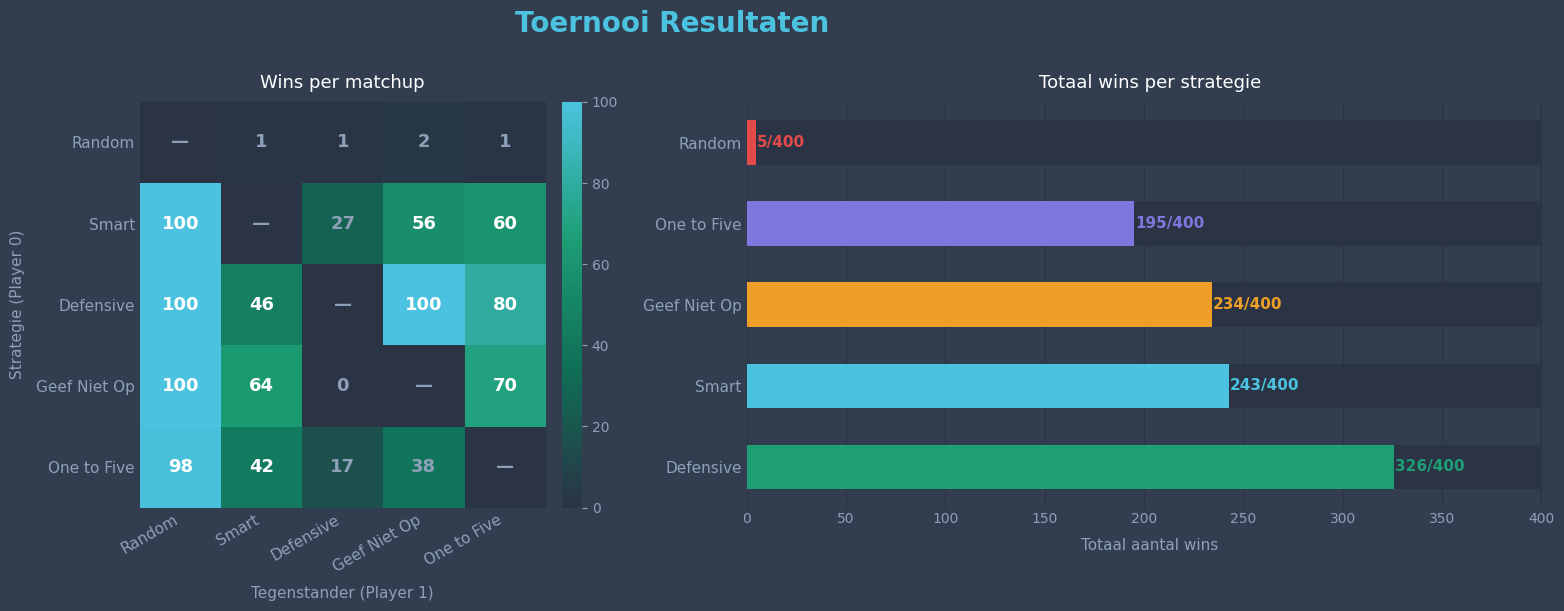

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

VIZ_BG     = '#323E50'
VIZ_TEXT   = '#FFFFFF'
VIZ_MUTED  = '#8DA0B8'
VIZ_EMPTY  = '#2A3444'

# Vaste kleuren per strategie — consistent over beide grafieken
STRATEGY_COLORS = {
    "Random":      "#E24B4A",   # rood
    "Smart":       "#4BC3E0",   # blauwgroen
    "Defensive":   "#1D9E75",   # groen
    "Geef Niet Op":"#EF9F27",   # amber
    "One to Five": "#7F77DD",   # paars
}
FALLBACK_COLORS = ["#4BC3E0","#1D9E75","#EF9F27","#7F77DD","#E24B4A"]


def visualize_tournament(results, names, rounds):
    """
    Visualiseer de resultaten van een strategietoernooi in twee grafieken.

    Genereert een figuur met twee subplots naast elkaar:
    een heatmap die de wins per matchup toont, en een horizontaal
    staafdiagram met de totale winscore per strategie.

    Parameters
    ----------
    results : dict of dict of dict
        Geneste dictionary met de structuur ``results[a][b]["wins"]``,
        waarbij ``a`` en ``b`` strategienamen zijn (strings uit ``names``).
        De waarde geeft het aantal keer dat strategie ``a`` won van ``b``.
    names : list of str
        Lijst met de namen van alle strategieën in het toernooi.
        De volgorde bepaalt de indeling van de assen in de heatmap.
    rounds : int
        Het aantal rondes dat elke matchup gespeeld is. Wordt gebruikt
        als bovengrens voor de kleurschaal van de heatmap en voor het
        berekenen van het maximale aantal te behalen wins.

    Returns
    -------
    None
        De functie toont de figuur direct via ``plt.show()``
        en geeft geen waarde terug.

    Notes
    -----
    - Strategieën die voorkomen in ``STRATEGY_COLORS`` krijgen hun
      vaste kleur toegewezen; onbekende strategieën vallen terug op
      ``FALLBACK_COLORS`` op basis van hun index.
    - De heatmap gebruikt een aangepast kleurverloop van donker naar
      blauwgroen. Diagonaalcellen (een strategie tegen zichzelf)
      worden weergegeven als ``—``.
    - Het staafdiagram sorteert strategieën aflopend op totaal aantal
      wins en toont achter elke balk een grijze achtergrondtrack voor
      het maximaal haalbare aantal wins ``(n - 1) * rounds``.

    Examples
    --------
    >>> results = {
    ...     "Random":    {"Smart": {"wins": 3}, "Defensive": {"wins": 7}},
    ...     "Smart":     {"Random": {"wins": 7}, "Defensive": {"wins": 6}},
    ...     "Defensive": {"Random": {"wins": 3}, "Smart": {"wins": 4}},
    ... }
    >>> names = ["Random", "Smart", "Defensive"]
    >>> visualize_tournament(results, names, rounds=10)
    """

    n = len(names)
    # Wijs een kleur toe aan elke strategie op basis van de kleurentabel
    colors = [STRATEGY_COLORS.get(name, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]) for i, name in enumerate(names)]

    # Bouw de winmatrix op: rijen = strategie, kolommen = tegenstander
    win_matrix = np.zeros((n, n))
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            if a != b:
                win_matrix[i, j] = results[a][b]["wins"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=VIZ_BG)
    fig.suptitle("Toernooi Resultaten", fontsize=20, fontweight="bold", color="#4BC3E0", y=1.01)

    # --- Heatmap ---
    ax = axes[0]
    ax.set_facecolor(VIZ_BG)

    # Aangepast kleurverloop: donkere achtergrond naar helder blauwgroen
    cmap = mcolors.LinearSegmentedColormap.from_list("teal_ramp", [VIZ_EMPTY, "#0F6E56", "#1D9E75", "#4BC3E0"])
    im = ax.imshow(win_matrix, cmap=cmap, vmin=0, vmax=rounds)

    # Schrijf het aantal wins in elke cel; diagonaal toont een streepje
    for i in range(n):
        for j in range(n):
            val = int(win_matrix[i, j])
            # Lichte tekst bij hoge waarden, gedempte tekst bij lage waarden
            text_color = VIZ_TEXT if win_matrix[i, j] > rounds * 0.4 else VIZ_MUTED
            ax.text(j, i, str(val) if i != j else "—",
                    ha="center", va="center",
                    color=text_color, fontsize=13, fontweight="bold")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

    # Kleur de aslabels per strategie
    xlabels = ax.set_xticklabels(names, rotation=30, ha="right", fontsize=11)
    ylabels = ax.set_yticklabels(names, fontsize=11)
    for lbl, col in zip(xlabels, colors): lbl.set_color(col)
    for lbl, col in zip(ylabels, colors): lbl.set_color(col)

    ax.set_xlabel("Tegenstander (Player 1)", color=VIZ_MUTED, fontsize=11, labelpad=8)
    ax.set_ylabel("Strategie (Player 0)",    color=VIZ_MUTED, fontsize=11, labelpad=8)
    ax.set_title("Wins per matchup", color=VIZ_TEXT, fontsize=13, pad=10)
    ax.tick_params(colors=VIZ_MUTED, length=0)
    for spine in ax.spines.values(): spine.set_visible(False)

    # Kleurenschaal naast de heatmap
    cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cb.ax.yaxis.set_tick_params(color=VIZ_MUTED, labelsize=10)
    cb.outline.set_visible(False)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=VIZ_MUTED)

    # --- Staafdiagram ---
    ax2 = axes[1]
    ax2.set_facecolor(VIZ_BG)

    # Bereken totale wins per strategie en sorteer aflopend
    totals = {name: sum(results[name][b]["wins"] for b in names if b != name) for name in names}
    sorted_items = sorted(totals.items(), key=lambda x: x[1], reverse=True)
    sorted_names  = [x[0] for x in sorted_items]
    sorted_wins   = [x[1] for x in sorted_items]
    sorted_colors = [STRATEGY_COLORS.get(n, "#4BC3E0") for n in sorted_names]
    max_games = (n - 1) * rounds  # Maximaal haalbare wins voor één strategie

    # Grijze achtergrondtrack toont het maximaal haalbare aantal wins
    ax2.barh(sorted_names, [max_games] * n, color=VIZ_EMPTY, zorder=0, height=0.55)
    # Gekleurde balkjes op de voorgrond
    bars = ax2.barh(sorted_names, sorted_wins, color=sorted_colors, zorder=1, height=0.55)

    # Voeg een score-label toe rechts van elke balk
    for bar, val, col in zip(bars, sorted_wins, sorted_colors):
        ax2.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                 f"{val}/{max_games}", va="center",
                 color=col, fontsize=11, fontweight="bold")

    # Kleur de y-aslabels per strategie
    for lbl in ax2.get_yticklabels():
        lbl.set_color(STRATEGY_COLORS.get(lbl.get_text(), VIZ_TEXT))

    ax2.set_xlim(0, max_games + 6)
    ax2.set_xlabel("Totaal aantal wins", color=VIZ_MUTED, fontsize=11, labelpad=8)
    ax2.set_title("Totaal wins per strategie", color=VIZ_TEXT, fontsize=13, pad=10)
    ax2.tick_params(colors=VIZ_MUTED, length=0)
    ax2.xaxis.set_tick_params(labelsize=10)
    ax2.yaxis.set_tick_params(labelsize=11)
    for spine in ax2.spines.values(): spine.set_visible(False)
    ax2.xaxis.grid(True, color=VIZ_EMPTY, linewidth=1, zorder=0)
    ax2.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


visualize_tournament(results, names, rounds=ROUNDS)

Door de strategiën tegen elkaar te laten spelen, hebben we de wins uit aantal games geplot. Uit de resultaten halen we dat de defense_strategy het best heeft gedaan. Dit komt doordat defense_strategy beter omgaat tegen forks situaties (ook toekomstige mogelijke forks), dan blokkeert hij dit op tijd.
Het feit dat random_strategy 5 keren heeft gewonnen, heeft te maken met de onvoorspelbaarheid van de strategie zelf.

## Bronnen

- Wikipedia, 4 Okt 2025. Vier op 'n rij. https://nl.wikipedia.org/wiki/Vier_op_%27n_rij
- Wikipedia, 27 Juli 2025. Rule-based system. https://en.wikipedia.org/wiki/Rule-based_system
- GeeksforGeeks, 6 Aug 2025. Rule Based System Vs Machine Learning System. https://www.geeksforgeeks.org/machine-learning/rule-based-system-vs-machine-learning-system/
- ScienceDirect, 2025. https://www.sciencedirect.com/topics/engineering/rule-based-system
